<a href="https://colab.research.google.com/github/roalddalhwriter/RootlessCones/blob/main/ElevationNew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rasterio sahi ultralytics -q

import rasterio
import numpy as np
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sahi.predict import get_sliced_prediction
from sahi.models.ultralytics import UltralyticsDetectionModel
from rasterio.transform import rowcol
from scipy.ndimage import map_coordinates
from scipy.signal import find_peaks
import pandas as pd

print('✅ Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.9 MB/s eta 0:00:00
✅ Done


In [2]:

ORTHO_PATH   = '/content/drive/MyDrive/Elevation/PSP_007882_2065_RED_A_01_ORTHO.JP2'
DTM_PATH     = '/content/drive/MyDrive/Elevation/DTEEC_007671_2065_007882_2065_U01.IMG'
YOLO_WEIGHTS = '/content/drive/MyDrive/Cones/runs/Icelandplusvers/weights/best.pt'
OUTPUT_DIR   = '/content/drive/MyDrive/cones/results/'
BROWSE_JPG   = '/content/drive/MyDrive/Elevation/ortho_browse.jpg'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Done')

✅ Done


In [3]:
SCALE_FACTOR = 0.0515   # brings JP2 to ~5m/pixel, matching training resolution

with rasterio.open(ORTHO_PATH) as src:
    full_w        = src.width
    full_h        = src.height
    ortho_px_m    = abs(src.transform.a)
    ortho_transform = src.transform

    out_w = int(full_w * SCALE_FACTOR)
    out_h = int(full_h * SCALE_FACTOR)
    browse_px_m = ortho_px_m / SCALE_FACTOR

    print(f'Full JP2    : {full_w} x {full_h} at {ortho_px_m:.3f} m/px')
    print(f'Browse JPG  : {out_w} x {out_h} at {browse_px_m:.1f} m/px')

    band = src.read(1, out_shape=(out_h, out_w)).astype(np.float32)

# Normalize to uint8
p2, p98 = np.percentile(band[band > 0], (2, 98))
img_u8  = np.clip((band - p2) / (p98 - p2 + 1e-6) * 255, 0, 255).astype(np.uint8)

# Save
cv2.imwrite(BROWSE_JPG, img_u8)
print(f'✅ Saved browse JPG to {BROWSE_JPG}')

Full JP2    : 29406 x 48553 at 0.252 m/px
Browse JPG  : 1514 x 2500 at 4.9 m/px
✅ Saved browse JPG to /content/drive/MyDrive/Elevation/ortho_browse.jpg


In [4]:
with rasterio.open(DTM_PATH) as src:
    dtm_raw       = src.read(1).astype(np.float32)
    dtm_transform = src.transform
    dtm_nodata    = src.nodata
    scale         = src.scales[0]  if src.scales  else 1.0
    offset        = src.offsets[0] if src.offsets else 0.0

dtm = dtm_raw * scale + offset
if dtm_nodata is not None:
    dtm[dtm_raw == dtm_nodata] = np.nan

print(f'DTM shape : {dtm.shape}')
print(f'Elevation : {np.nanmin(dtm):.1f} m → {np.nanmax(dtm):.1f} m')
print(f'DTM px res: {abs(dtm_transform.a):.3f} m/px')
print('✅ DTM loaded')

DTM shape : (12139, 7351)
Elevation : -3231.6 m → -3169.3 m
DTM px res: 1.007 m/px
✅ DTM loaded


In [5]:
detection_model = UltralyticsDetectionModel(
    model_path           = YOLO_WEIGHTS,
    confidence_threshold = 0.25,
    device               = 'cuda:0'
)

result = get_sliced_prediction(
    BROWSE_JPG,
    detection_model,
    slice_height         = 1260,
    slice_width          = 1260,
    overlap_height_ratio = 0.2,
    overlap_width_ratio  = 0.2,
    verbose              = 1
)

print(f'✅ Total detections: {len(result.object_prediction_list)}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Performing prediction on 6 slices.
✅ Total detections: 740


In [6]:
DTM_PX_M = abs(dtm_transform.a)

detections = []
for op in result.object_prediction_list:
    xmin, ymin, xmax, ymax = op.bbox.to_xyxy()
    conf = op.score.value

    # Centroid in browse JPG pixel space
    cx_browse = (xmin + xmax) / 2.0
    cy_browse = (ymin + ymax) / 2.0
    bbox_w_browse = xmax - xmin
    bbox_h_browse = ymax - ymin

    # Browse pixel → full ortho pixel
    cx_ortho = cx_browse / SCALE_FACTOR
    cy_ortho = cy_browse / SCALE_FACTOR

    # Full ortho pixel → geographic coords
    geo_x, geo_y = ortho_transform * (cx_ortho, cy_ortho)

    # Geographic coords → DTM pixel
    dtm_r, dtm_c = rowcol(dtm_transform, geo_x, geo_y)

    # Cone radius in DTM pixels
    radius_m   = (bbox_w_browse / 2.0) * (ortho_px_m / SCALE_FACTOR)
    radius_dtm = int(radius_m / DTM_PX_M)

    detections.append({
        'cx_browse' : cx_browse,
        'cy_browse' : cy_browse,
        'cx_dtm'    : int(dtm_c),
        'cy_dtm'    : int(dtm_r),
        'bbox_w_m'  : bbox_w_browse * (ortho_px_m / SCALE_FACTOR),
        'radius_dtm': max(radius_dtm, 30),  # minimum 30 DTM px
        'conf'      : conf
    })

print(f'Total detections mapped to DTM: {len(detections)}')

# Sanity check bbox sizes
sizes = [d['bbox_w_m'] for d in detections]
print(f'Bbox width — Min: {np.min(sizes):.0f}m  Max: {np.max(sizes):.0f}m  Mean: {np.mean(sizes):.0f}m')

Total detections mapped to DTM: 740
Bbox width — Min: 30m  Max: 463m  Mean: 90m


In [7]:
def extract_profile(dem, cx, cy, half_len, direction='EW', n_samples=200):
    half_len = max(half_len, 30)
    if direction == 'EW':
        cols = np.linspace(cx - half_len, cx + half_len, n_samples)
        rows = np.full(n_samples, cy)
    else:
        rows = np.linspace(cy - half_len, cy + half_len, n_samples)
        cols = np.full(n_samples, cx)

    rows = np.clip(rows, 0, dem.shape[0] - 1)
    cols = np.clip(cols, 0, dem.shape[1] - 1)

    profile  = map_coordinates(dem, [rows, cols], order=1, mode='nearest')
    profile[profile < -9000] = np.nan

    total_m   = 2 * half_len * DTM_PX_M
    distances = np.linspace(-total_m / 2, total_m / 2, n_samples)
    return profile, distances


for d in detections:
    half = d['radius_dtm'] * 2
    d['profile_ew'], d['dist_ew'] = extract_profile(dtm, d['cx_dtm'], d['cy_dtm'], half, 'EW')
    d['profile_ns'], d['dist_ns'] = extract_profile(dtm, d['cx_dtm'], d['cy_dtm'], half, 'NS')

print('✅ Profiles extracted')

✅ Profiles extracted


In [8]:
MIN_HEIGHT_M     = 5.0
MIN_WIDTH_M      = 30.0
MAX_NAN_FRACTION = 0.15
PEAK_PROMINENCE  = 3.0

def validate_profile(profile, distances):
    nan_frac = np.isnan(profile).mean()
    if nan_frac > MAX_NAN_FRACTION:
        return False, f'too many NaNs ({nan_frac:.0%})', {}

    valid_mask = ~np.isnan(profile)
    p = profile.copy()
    if np.any(~valid_mask) and np.sum(valid_mask) > 2:
        p = np.interp(np.arange(len(p)), np.where(valid_mask)[0], p[valid_mask])

    relief  = p.max() - p.min()
    width_m = distances[-1] - distances[0]
    peaks, _ = find_peaks(p, prominence=PEAK_PROMINENCE)

    if relief < MIN_HEIGHT_M:
        return False, f'low relief ({relief:.1f}m)', {}
    if width_m < MIN_WIDTH_M:
        return False, f'too narrow ({width_m:.1f}m)', {}
    if len(peaks) < 1:
        return False, 'no peaks', {}

    base_elev   = float(np.nanmean([profile[0], profile[-1]]))
    summit_elev = float(np.nanmax(profile))
    center_val  = profile[len(profile)//2]
    crater_elev = float(center_val) if not np.isnan(center_val) else summit_elev

    metrics = {
        'base_elev_m'   : round(base_elev, 2),
        'summit_elev_m' : round(summit_elev, 2),
        'cone_height_m' : round(summit_elev - base_elev, 2),
        'crater_depth_m': round(summit_elev - crater_elev, 2),
        'width_m'       : round(width_m, 2),
        'h_w_ratio'     : round((summit_elev - base_elev) / width_m if width_m > 0 else 0, 4),
        'num_peaks'     : len(peaks)
    }
    return True, 'PASS', metrics


valid_detections = []
for i, d in enumerate(detections):
    ok_ew, reason_ew, metrics_ew = validate_profile(d['profile_ew'], d['dist_ew'])
    ok_ns, reason_ns, metrics_ns = validate_profile(d['profile_ns'], d['dist_ns'])
    d['valid']      = ok_ew and ok_ns
    d['metrics_ew'] = metrics_ew
    d['metrics_ns'] = metrics_ns
    if d['valid']:
        valid_detections.append(d)

print(f'✅ Valid cones   : {len(valid_detections)}')
print(f'❌ Rejected      : {len(detections) - len(valid_detections)}')

✅ Valid cones   : 389
❌ Rejected      : 351


In [ ]:
import os
os.makedirs(OUTPUT_DIR + 'profiles/', exist_ok=True)

for i, d in enumerate(valid_detections):
    cone_id = detections.index(d)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # DTM chip
    half = d['radius_dtm'] * 3
    r0 = max(0, d['cy_dtm'] - half);  r1 = min(dtm.shape[0], d['cy_dtm'] + half)
    c0 = max(0, d['cx_dtm'] - half);  c1 = min(dtm.shape[1], d['cx_dtm'] + half)
    chip = dtm[r0:r1, c0:c1]
    axes[0].imshow(chip, cmap='terrain',
                   vmin=np.nanpercentile(chip, 2),
                   vmax=np.nanpercentile(chip, 98))
    axes[0].plot(d['cx_dtm'] - c0, d['cy_dtm'] - r0, 'r+', markersize=10, mew=2)
    axes[0].set_title(f'Cone {cone_id} | conf={d["conf"]:.2f}', fontsize=9)
    axes[0].axis('off')

    # EW
    axes[1].plot(d['dist_ew'], d['profile_ew'], color='#c0392b', lw=1.5)
    axes[1].set_xlabel('Distance (m)')
    axes[1].set_ylabel('Elevation (m)')
    axes[1].set_title(f'E-W | H={d["metrics_ew"]["cone_height_m"]:.1f}m '
                      f'W={d["metrics_ew"]["width_m"]:.0f}m', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    # NS
    axes[2].plot(d['dist_ns'], d['profile_ns'], color='#2980b9', lw=1.5)
    axes[2].set_xlabel('Distance (m)')
    axes[2].set_ylabel('Elevation (m)')
    axes[2].set_title(f'N-S | H={d["metrics_ns"]["cone_height_m"]:.1f}m '
                      f'W={d["metrics_ns"]["width_m"]:.0f}m', fontsize=9)
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'Cone {cone_id}', fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'profiles/cone_{cone_id:03d}.png', dpi=100, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 50 == 0:
        print(f'  Saved {i+1}/{len(valid_detections)} profiles...')

print(f'✅ All {len(valid_detections)} profiles saved to {OUTPUT_DIR}profiles/')

  Saved 50/389 profiles...
  Saved 100/389 profiles...
  Saved 150/389 profiles...
  Saved 200/389 profiles...
  Saved 250/389 profiles...
  Saved 300/389 profiles...
  Saved 350/389 profiles...
✅ All 389 profiles saved to /content/drive/MyDrive/cones/results/profiles/


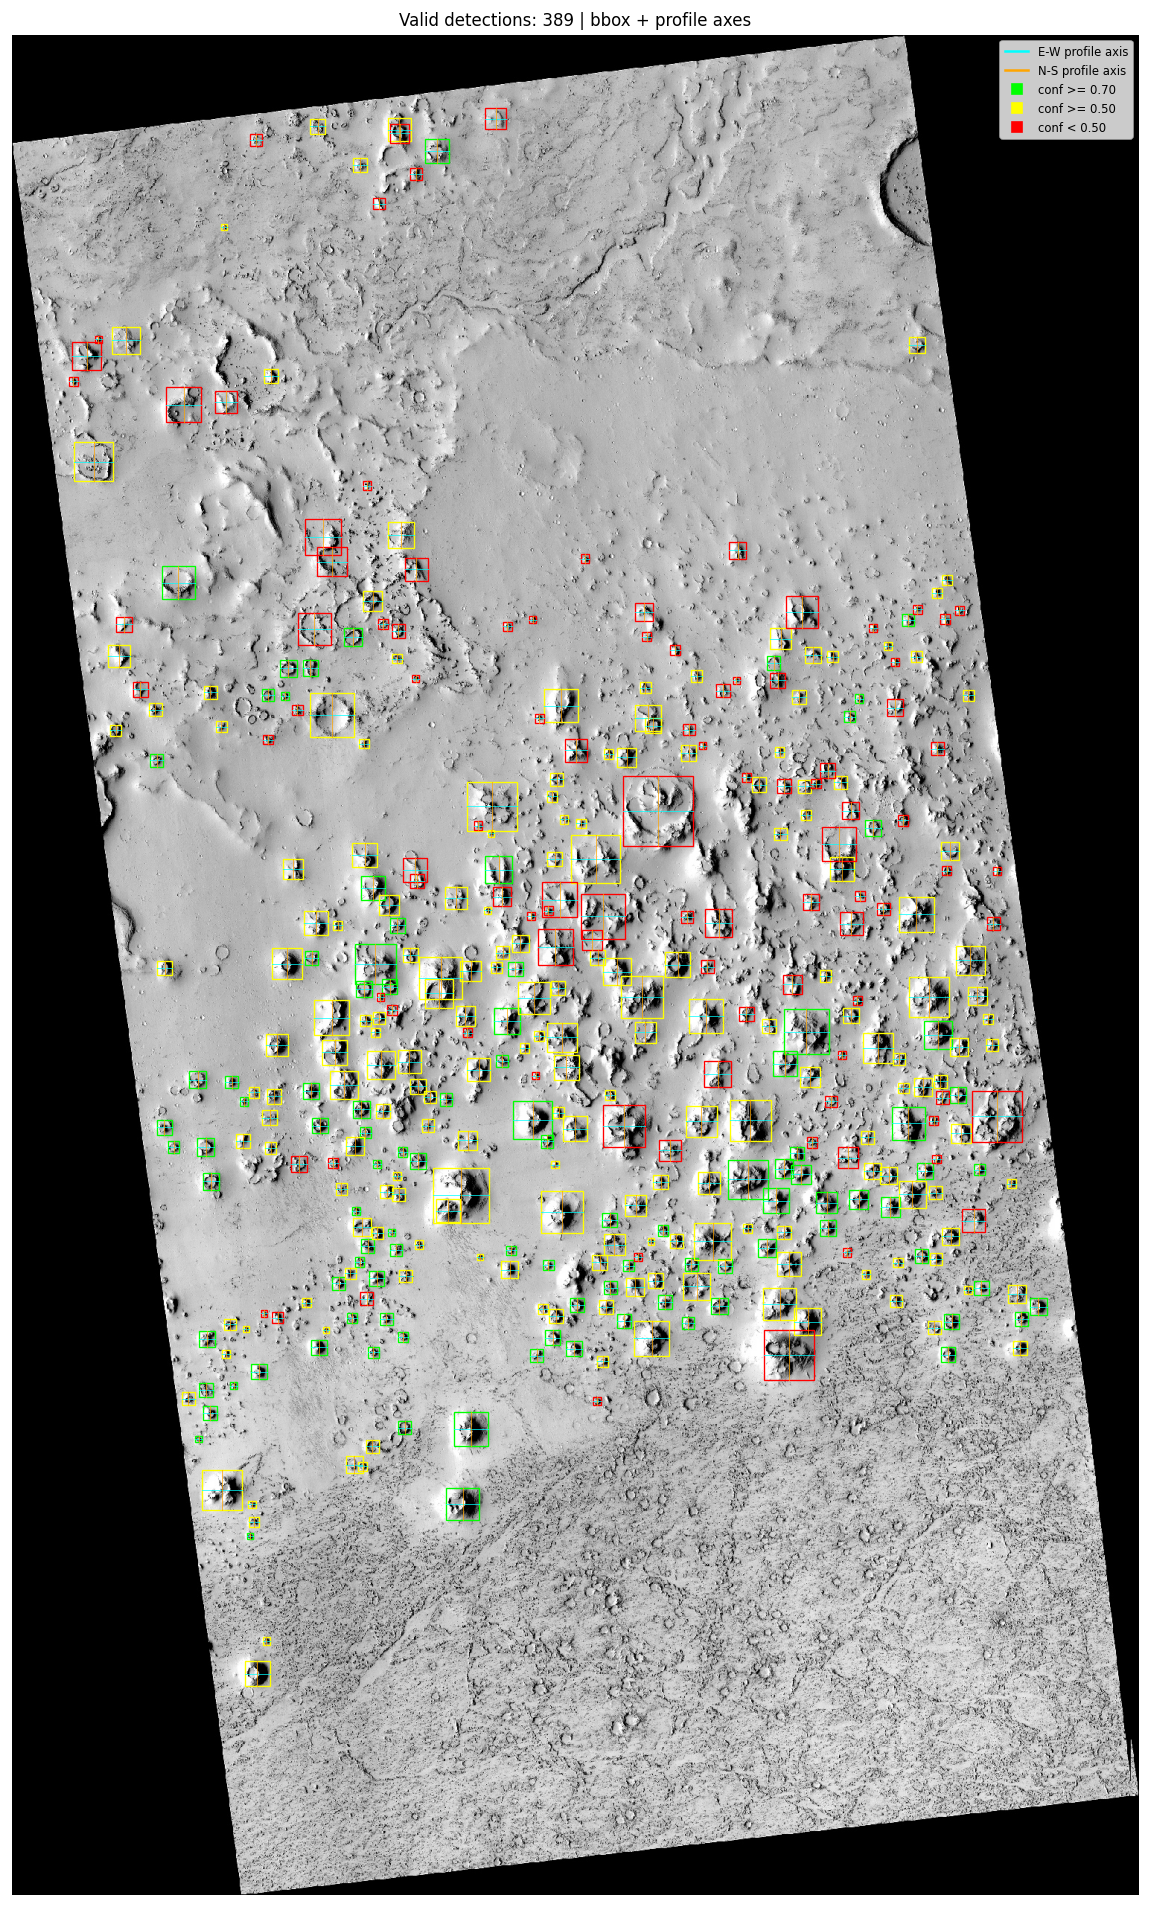

✅ Done


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

img = Image.open(BROWSE_JPG).convert('RGB')
img_arr = np.array(img)

fig, ax = plt.subplots(figsize=(10, 16), dpi=120)
ax.imshow(img_arr, cmap='gray')

for d in valid_detections:
    cx = d['cx_browse']
    cy = d['cy_browse']
    w  = d['bbox_w_m'] * SCALE_FACTOR / ortho_px_m   # back to browse pixels
    h  = w  # approximate square box

    conf = d['conf']
    if conf >= 0.70:
        color = 'lime'
    elif conf >= 0.50:
        color = 'yellow'
    else:
        color = 'red'

    # Bounding box
    rect = patches.Rectangle(
        (cx - w/2, cy - h/2), w, h,
        linewidth=0.8, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)

    # E-W line
    ax.plot([cx - w/2, cx + w/2], [cy, cy],
            color='cyan', linewidth=0.6, alpha=0.7)

    # N-S line
    ax.plot([cx, cx], [cy - h/2, cy + h/2],
            color='orange', linewidth=0.6, alpha=0.7)

# Legend
ax.plot([], [], '-', color='cyan',   label='E-W profile axis')
ax.plot([], [], '-', color='orange', label='N-S profile axis')
ax.plot([], [], 's', color='lime',   label='conf >= 0.70', markersize=6)
ax.plot([], [], 's', color='yellow', label='conf >= 0.50', markersize=6)
ax.plot([], [], 's', color='red',    label='conf < 0.50',  markersize=6)

ax.legend(loc='upper right', fontsize=7)
ax.set_title(f'Valid detections: {len(valid_detections)} | bbox + profile axes', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'detections_bbox.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Done')

Total: 389
Min   : 38 m
Max   : 463 m
Mean  : 112 m
Median: 93 m
  bbox_w >= 50m : 366 detections
  bbox_w >= 75m : 267 detections
  bbox_w >= 100m : 160 detections
  bbox_w >= 125m : 108 detections
  bbox_w >= 150m : 79 detections
  bbox_w >= 175m : 56 detections
  bbox_w >= 200m : 42 detections


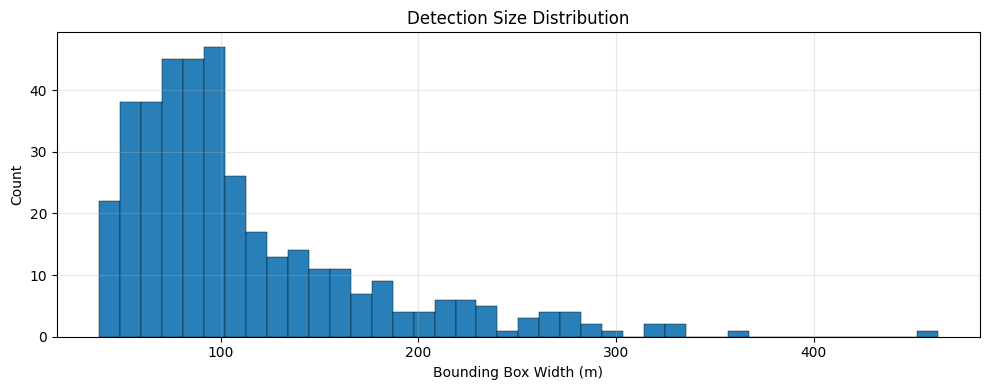

In [9]:
import numpy as np
import matplotlib.pyplot as plt

sizes = [d['bbox_w_m'] for d in valid_detections]
print(f'Total: {len(sizes)}')
print(f'Min   : {np.min(sizes):.0f} m')
print(f'Max   : {np.max(sizes):.0f} m')
print(f'Mean  : {np.mean(sizes):.0f} m')
print(f'Median: {np.median(sizes):.0f} m')

for thresh in [50, 75, 100, 125, 150, 175, 200]:
    count = sum(1 for s in sizes if s >= thresh)
    print(f'  bbox_w >= {thresh}m : {count} detections')

plt.figure(figsize=(10, 4))
plt.hist(sizes, bins=40, color='#2980b9', edgecolor='black', linewidth=0.3)
plt.xlabel('Bounding Box Width (m)')
plt.ylabel('Count')
plt.title('Detection Size Distribution')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()